<a href="https://colab.research.google.com/github/Akshat21112005/DermaScanX/blob/main/tfefficientnetv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1: Install & Imports
# ─────────────────────────────────────────────────────────────
!pip install -q timm albumentations scikit-learn pandas matplotlib seaborn tqdm

import os
import gc
import cv2
import math
import time
import copy
import random
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.cuda.amp import autocast, GradScaler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", DEVICE)
if torch.cuda.is_available():
    print("✅ GPU:", torch.cuda.get_device_name(0))

✅ Device: cuda
✅ GPU: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ========= CHANGE THESE PATHS IF NEEDED =========
ZIP_DIR = "/content/drive/MyDrive/dataset/images"
CSV_PATH = "/content/drive/MyDrive/dataset/metadata.csv"
EXTRACT_PATH = "/content/dataset_images"
SAVE_DIR = "/content/drive/MyDrive/skin_cancer_project/effv2l_high_accuracy"
# ================================================

os.makedirs(EXTRACT_PATH, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

zip_files = [f for f in os.listdir(ZIP_DIR) if f.endswith(".zip")]
print(f"✅ Found ZIP files: {len(zip_files)}")

for file in zip_files:
    zip_path = os.path.join(ZIP_DIR, file)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(EXTRACT_PATH)

print("✅ All ZIP files extracted")
print("Top-level contents:", os.listdir(EXTRACT_PATH)[:10])

Mounted at /content/drive
✅ Found ZIP files: 3
✅ All ZIP files extracted
Top-level contents: ['imgs_part_3', 'imgs_part_1', 'imgs_part_2']


In [3]:
df = pd.read_csv(CSV_PATH)

# Adjust according to your dataset labels
MALIGNANT_CLASSES = ['BCC', 'MEL', 'SCC']

df['label'] = df['diagnostic'].apply(lambda x: 1 if x in MALIGNANT_CLASSES else 0)
df['label_str'] = df['label'].map({0: 'benign', 1: 'malignant'})

print("✅ Metadata loaded")
print(df.head())
print("\nClass distribution:")
print(df['label_str'].value_counts())

label_counts = df['label'].value_counts()
if 0 in label_counts and 1 in label_counts:
    print(f"\nClass imbalance ratio (benign:malignant) = {label_counts[0] / label_counts[1]:.2f}:1")


✅ Metadata loaded
  patient_id  lesion_id  smoke  drink background_father background_mother  \
0   PAT_1516       1765    NaN    NaN               NaN               NaN   
1     PAT_46        881  False  False         POMERANIA         POMERANIA   
2   PAT_1545       1867    NaN    NaN               NaN               NaN   
3   PAT_1989       4061    NaN    NaN               NaN               NaN   
4    PAT_684       1302  False   True         POMERANIA         POMERANIA   

   age pesticide  gender skin_cancer_history  ...   itch   grew   hurt  \
0    8       NaN     NaN                 NaN  ...  False  False  False   
1   55     False  FEMALE                True  ...   True   True  False   
2   77       NaN     NaN                 NaN  ...   True  False  False   
3   75       NaN     NaN                 NaN  ...   True  False  False   
4   79     False    MALE                True  ...   True   True  False   

   changed  bleed  elevation                 img_id biopsed label  label_s

In [4]:
def find_image_path(img_id, base_dir=EXTRACT_PATH):
    for part in os.listdir(base_dir):
        part_path = os.path.join(base_dir, part)
        if os.path.isdir(part_path):
            possible_path = os.path.join(part_path, img_id)
            if os.path.exists(possible_path):
                return possible_path
    return None

df['path'] = df['img_id'].apply(find_image_path)

missing = df['path'].isna().sum()
df = df.dropna(subset=['path']).reset_index(drop=True)

print(f"✅ Found {len(df)} images")
print(f"⚠️ Missing images: {missing}")

✅ Found 2298 images
⚠️ Missing images: 0


In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print(f"Train: {len(train_df)}")
print(f"Val  : {len(val_df)}")
print(f"Test : {len(test_df)}")

print("\nTrain label distribution:")
print(train_df['label_str'].value_counts())
print("\nVal label distribution:")
print(val_df['label_str'].value_counts())
print("\nTest label distribution:")
print(test_df['label_str'].value_counts())

Train: 1608
Val  : 345
Test : 345

Train label distribution:
label_str
benign       846
malignant    762
Name: count, dtype: int64

Val label distribution:
label_str
benign       181
malignant    164
Name: count, dtype: int64

Test label distribution:
label_str
benign       182
malignant    163
Name: count, dtype: int64


In [6]:
CONFIG = {
    "IMG_SIZE": 384,
    "BATCH_SIZE": 8,               # safe for 16 GB GPU with effv2-l
    "ACCUM_STEPS": 2,              # effective batch size = 16
    "NUM_WORKERS": 2,
    "EPOCHS": 20,
    "LR_HEAD": 2e-4,
    "LR_BACKBONE": 5e-5,
    "WEIGHT_DECAY": 1e-4,
    "PATIENCE": 6,
    "MODEL_NAME": "tf_efficientnetv2_l.in21k_ft_in1k",
    "USE_TTA": True,
    "TTA_TIMES": 4,
    "FOCAL_GAMMA": 2.0,
    "LABEL_SMOOTHING": 0.05
}

print("✅ Config loaded")
for k, v in CONFIG.items():
    print(f"{k}: {v}")


✅ Config loaded
IMG_SIZE: 384
BATCH_SIZE: 8
ACCUM_STEPS: 2
NUM_WORKERS: 2
EPOCHS: 20
LR_HEAD: 0.0002
LR_BACKBONE: 5e-05
WEIGHT_DECAY: 0.0001
PATIENCE: 6
MODEL_NAME: tf_efficientnetv2_l.in21k_ft_in1k
USE_TTA: True
TTA_TIMES: 4
FOCAL_GAMMA: 2.0
LABEL_SMOOTHING: 0.05


In [7]:
IMG_SIZE = CONFIG["IMG_SIZE"]

train_transform = A.Compose([
    A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.75, 1.0), ratio=(0.85, 1.15)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.06,
        scale_limit=0.10,
        rotate_limit=25,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.5
    ),

    A.OneOf([
        A.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.20, hue=0.08),
        A.HueSaturationValue(hue_shift_limit=12, sat_shift_limit=20, val_shift_limit=15),
    ], p=0.6),

    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5)),
        A.MotionBlur(blur_limit=5),
        A.GaussNoise(std_range=(0.01, 0.05), mean_range=(0.0, 0.0)),
    ], p=0.25),

    A.OneOf([
        A.OpticalDistortion(distort_limit=0.05),
        A.GridDistortion(num_steps=5, distort_limit=0.05),
        A.ElasticTransform(alpha=1.0, sigma=25.0),
    ], p=0.20),

    A.CoarseDropout(
        num_holes_range=(1, 6),
        hole_height_range=(0.05, 0.15),
        hole_width_range=(0.05, 0.15),
        p=0.25
    ),

    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

print("✅ Augmentations ready")

✅ Augmentations ready


In [8]:
class SkinCancerDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.array(Image.open(row['path']).convert("RGB"))
        label = int(row['label'])

        if self.transform is not None:
            image = self.transform(image=image)['image']

        return image, torch.tensor(label, dtype=torch.long)


train_ds = SkinCancerDataset(train_df, transform=train_transform)
val_ds   = SkinCancerDataset(val_df, transform=val_transform)
test_ds  = SkinCancerDataset(test_df, transform=val_transform)

print("✅ Datasets created")

✅ Datasets created


In [9]:
train_labels = train_df['label'].values
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["BATCH_SIZE"],
    sampler=sampler,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=CONFIG["BATCH_SIZE"],
    shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=True
)

print("✅ DataLoaders ready")
print(f"Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")


✅ DataLoaders ready
Train batches: 201 | Val: 44 | Test: 44


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(
            logits,
            targets,
            weight=self.alpha,
            reduction='none',
            label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()


loss_class_weights = torch.tensor(
    [1.0, class_counts[0] / class_counts[1]],
    dtype=torch.float32
).to(DEVICE)

criterion = FocalLoss(
    alpha=loss_class_weights,
    gamma=CONFIG["FOCAL_GAMMA"],
    label_smoothing=CONFIG["LABEL_SMOOTHING"]
)

print("✅ Focal Loss ready")
print("Class weights:", loss_class_weights.cpu().numpy())

✅ Focal Loss ready
Class weights: [1.        1.1102362]


In [11]:
class SkinCancerModel(nn.Module):
    def __init__(self, model_name, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )

        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(0.35),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.25),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        return x


model = SkinCancerModel(CONFIG["MODEL_NAME"], pretrained=True).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✅ Model created")
print(f"Model: {CONFIG['MODEL_NAME']}")
print(f"Total params: {total_params / 1e6:.2f}M")
print(f"Trainable params: {trainable_params / 1e6:.2f}M")

model.safetensors:   0%|          | 0.00/476M [00:00<?, ?B/s]

✅ Model created
Model: tf_efficientnetv2_l.in21k_ft_in1k
Total params: 117.89M
Trainable params: 117.89M


In [12]:
backbone_params = [p for n, p in model.named_parameters() if 'backbone' in n]
head_params = [p for n, p in model.named_parameters() if 'backbone' not in n]

optimizer = AdamW([
    {"params": backbone_params, "lr": CONFIG["LR_BACKBONE"]},
    {"params": head_params, "lr": CONFIG["LR_HEAD"]}
], weight_decay=CONFIG["WEIGHT_DECAY"])

scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=4,
    T_mult=1,
    eta_min=1e-6
)

scaler = GradScaler()

print("✅ Optimizer, Scheduler, AMP ready")

✅ Optimizer, Scheduler, AMP ready


In [13]:
def compute_best_threshold(y_true, y_prob):
    thresholds = np.arange(0.20, 0.81, 0.01)
    best_thr = 0.50
    best_score = -1

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        # malignant recall ko thoda extra importance diya
        score = 0.65 * rec + 0.35 * f1

        if score > best_score:
            best_score = score
            best_thr = thr

    return best_thr, best_score


def get_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "threshold": threshold
    }
    return metrics, y_pred


def train_one_epoch(model, loader, optimizer, criterion, scaler, device, accum_steps=1):
    model.train()
    running_loss = 0.0
    total_samples = 0

    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(enumerate(loader), total=len(loader), desc="Train", leave=False)

    for step, (images, labels) in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)
            loss = loss / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * images.size(0) * accum_steps
        total_samples += images.size(0)

        pbar.set_postfix(loss=f"{running_loss / total_samples:.4f}")

    return running_loss / total_samples


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_probs = []
    all_labels = []

    pbar = tqdm(loader, total=len(loader), desc="Val", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)

        probs = F.softmax(logits, dim=1)[:, 1]

        running_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    best_thr, _ = compute_best_threshold(all_labels, all_probs)
    metrics, _ = get_metrics(all_labels, all_probs, threshold=best_thr)

    return running_loss / total_samples, metrics, all_labels, all_probs


@torch.no_grad()
def tta_predict(model, images):
    preds = []

    logits = model(images)
    preds.append(F.softmax(logits, dim=1))

    logits = model(torch.flip(images, dims=[-1]))   # hflip
    preds.append(F.softmax(logits, dim=1))

    logits = model(torch.flip(images, dims=[-2]))   # vflip
    preds.append(F.softmax(logits, dim=1))

    logits = model(torch.flip(images, dims=[-1, -2]))  # both
    preds.append(F.softmax(logits, dim=1))

    return torch.stack(preds, dim=0).mean(dim=0)


@torch.no_grad()
def evaluate_test(model, loader, criterion, device, threshold=0.5, use_tta=True):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_probs = []
    all_labels = []

    pbar = tqdm(loader, total=len(loader), desc="Test", leave=False)

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast():
            logits = model(images)
            loss = criterion(logits, labels)

        if use_tta:
            probs = tta_predict(model, images)[:, 1]
        else:
            probs = F.softmax(logits, dim=1)[:, 1]

        running_loss += loss.item() * images.size(0)
        total_samples += images.size(0)

        all_probs.extend(probs.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    metrics, y_pred = get_metrics(all_labels, all_probs, threshold=threshold)
    cm = confusion_matrix(all_labels, y_pred)

    return running_loss / total_samples, metrics, all_labels, all_probs, y_pred, cm


print("✅ Helper functions ready")

✅ Helper functions ready


In [14]:
history = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_threshold": []
}

best_auc = -np.inf
best_f1 = -np.inf
best_epoch = -1
best_threshold = 0.5
patience_counter = 0

best_model_path = os.path.join(SAVE_DIR, "best_model.pth")

print("\n" + "=" * 70)
print(f"Training started | Model: {CONFIG['MODEL_NAME']} | Device: {DEVICE}")
print("=" * 70)

for epoch in range(1, CONFIG["EPOCHS"] + 1):
    print(f"\nEpoch [{epoch}/{CONFIG['EPOCHS']}]")

    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=DEVICE,
        accum_steps=CONFIG["ACCUM_STEPS"]
    )

    val_loss, val_metrics, val_labels, val_probs = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    scheduler.step(epoch - 1)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_metrics["accuracy"])
    history["val_auc"].append(val_metrics["auc"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_threshold"].append(val_metrics["threshold"])

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Best Thr: {val_metrics['threshold']:.2f}"
    )

    # Save best based on AUC first, and F1 second
    improved = False
    if val_metrics["auc"] > best_auc:
        improved = True
    elif val_metrics["auc"] >= best_auc - 1e-4 and val_metrics["f1"] > best_f1:
        improved = True

    if improved:
        best_auc = val_metrics["auc"]
        best_f1 = val_metrics["f1"]
        best_epoch = epoch
        best_threshold = val_metrics["threshold"]
        patience_counter = 0

        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_auc": best_auc,
            "best_f1": best_f1,
            "best_threshold": best_threshold,
            "config": CONFIG
        }, best_model_path)

        print(f"💾 Best model saved | AUC: {best_auc:.4f} | F1: {best_f1:.4f} | Thr: {best_threshold:.2f}")
    else:
        patience_counter += 1
        print(f"Patience: {patience_counter}/{CONFIG['PATIENCE']}")

        if patience_counter >= CONFIG["PATIENCE"]:
            print("⏹ Early stopping triggered")
            break

    gc.collect()
    torch.cuda.empty_cache()

print("\n✅ Training complete")
print(f"Best Epoch: {best_epoch}")
print(f"Best Val AUC: {best_auc:.4f}")
print(f"Best Val F1: {best_f1:.4f}")
print(f"Best Threshold: {best_threshold:.2f}")


Training started | Model: tf_efficientnetv2_l.in21k_ft_in1k | Device: cuda

Epoch [1/20]


Train Loss: 0.2640 | Val Loss: 0.1687 | Val Acc: 0.6029 | Val AUC: 0.8182 | Val Precision: 0.5458 | Val Recall: 0.9817 | Val F1: 0.7015 | Best Thr: 0.21
💾 Best model saved | AUC: 0.8182 | F1: 0.7015 | Thr: 0.21

Epoch [2/20]


Train Loss: 0.2052 | Val Loss: 0.1510 | Val Acc: 0.6609 | Val AUC: 0.8462 | Val Precision: 0.5855 | Val Recall: 0.9817 | Val F1: 0.7335 | Best Thr: 0.27
💾 Best model saved | AUC: 0.8462 | F1: 0.7335 | Thr: 0.27

Epoch [3/20]


Train Loss: 0.1768 | Val Loss: 0.1318 | Val Acc: 0.6783 | Val AUC: 0.8827 | Val Precision: 0.5978 | Val Recall: 0.9878 | Val F1: 0.7448 | Best Thr: 0.24
💾 Best model saved | AUC: 0.8827 | F1: 0.7448 | Thr: 0.24

Epoch [4/20]


Train Loss: 0.1557 | Val Loss: 0.1225 | Val Acc: 0.7652 | Val AUC: 0.9095 | Val Precision: 0.6722 | Val Recall: 0.9878 | Val F1: 0.8000 | Best Thr: 0.26
💾 Best model saved | AUC: 0.9095 | F1: 0.8000 | Thr: 0.26

Epoch [5/20]


...

Train Loss: 0.1351 | Val Loss: 0.1560 | Val Acc: 0.6348 | Val AUC: 0.8530 | Val Precision: 0.5664 | Val Recall: 0.9878 | Val F1: 0.7200 | Best Thr: 0.21
Patience: 2/6

Epoch [7/20]


Train Loss: 0.1303 | Val Loss: 0.1199 | Val Acc: 0.7304 | Val AUC: 0.9047 | Val Precision: 0.6414 | Val Recall: 0.9817 | Val F1: 0.7759 | Best Thr: 0.27
Patience: 3/6

Epoch [8/20]


Train Loss: 0.1162 | Val Loss: 0.1262 | Val Acc: 0.8087 | Val AUC: 0.9043 | Val Precision: 0.7227 | Val Recall: 0.9695 | Val F1: 0.8281 | Best Thr: 0.32
Patience: 4/6

Epoch [9/20]


Train Loss: 0.1109 | Val Loss: 0.1187 | Val Acc: 0.8464 | Val AUC: 0.9074 | Val Precision: 0.7707 | Val Recall: 0.9634 | Val F1: 0.8564 | Best Thr: 0.37
Patience: 5/6

Epoch [10/20]


Train Loss: 0.1274 | Val Loss: 0.1294 | Val Acc: 0.7304 | Val AUC: 0.9069 | Val Precision: 0.6414 | Val Recall: 0.9817 | Val F1: 0.7759 | Best Thr: 0.38
Patience: 6/6
⏹ Early stopping triggered

✅ Training complete
Best Epoch: 4
Best Val AUC: 0.9095
Best Val F1: 0.8000
Best Threshold: 0.26


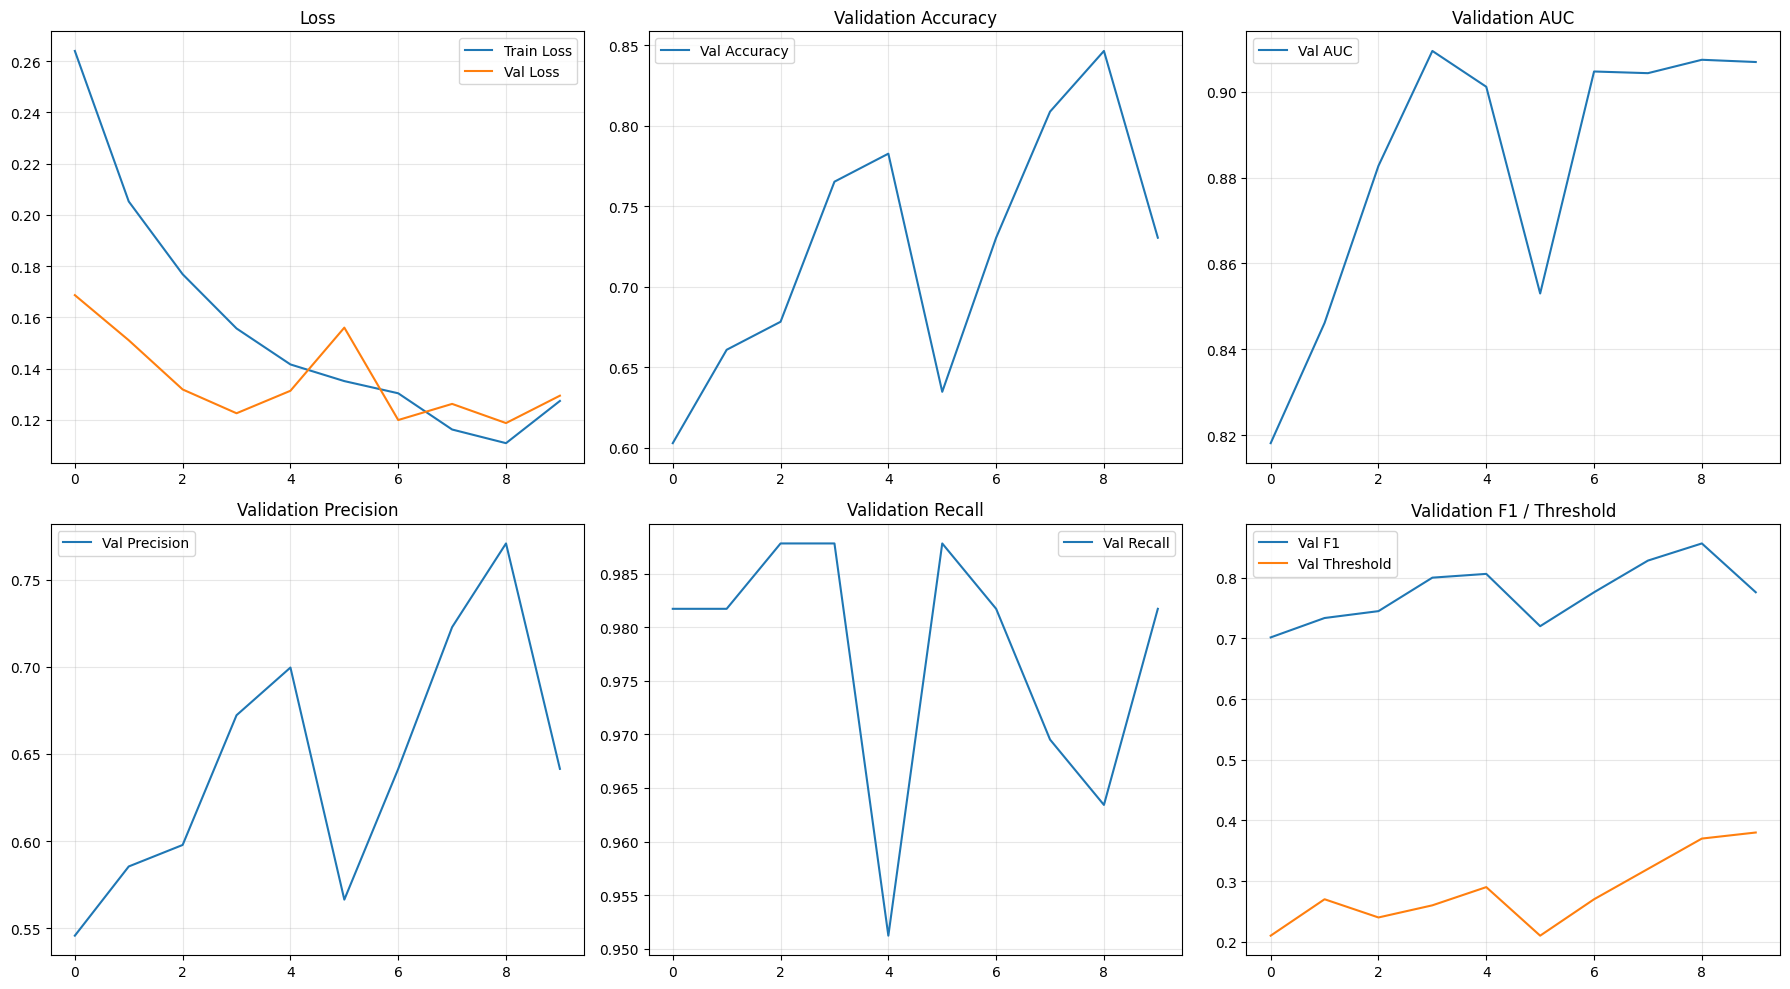

✅ Training curves saved


In [15]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(history["val_acc"], label="Val Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(history["val_auc"], label="Val AUC")
plt.title("Validation AUC")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 3, 4)
plt.plot(history["val_precision"], label="Val Precision")
plt.title("Validation Precision")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 3, 5)
plt.plot(history["val_recall"], label="Val Recall")
plt.title("Validation Recall")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 3, 6)
plt.plot(history["val_f1"], label="Val F1")
plt.plot(history["val_threshold"], label="Val Threshold")
plt.title("Validation F1 / Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"), dpi=150)
plt.show()

print("✅ Training curves saved")

In [17]:
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

best_threshold = checkpoint.get("best_threshold", 0.5)

print("✅ Best model loaded")
print(f"Best epoch: {checkpoint['epoch']}")
print(f"Best AUC  : {checkpoint['best_auc']:.4f}")
print(f"Best F1   : {checkpoint['best_f1']:.4f}")
print(f"Threshold : {best_threshold:.2f}")

✅ Best model loaded
Best epoch: 4
Best AUC  : 0.9095
Best F1   : 0.8000
Threshold : 0.26


In [18]:
test_loss, test_metrics, test_labels, test_probs, test_preds, cm = evaluate_test(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
    threshold=best_threshold,
    use_tta=CONFIG["USE_TTA"]
)

print("\n" + "=" * 60)
print("TEST RESULTS")
print("=" * 60)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_metrics['accuracy']:.4f}")
print(f"Test AUC      : {test_metrics['auc']:.4f}")
print(f"Test Precision: {test_metrics['precision']:.4f}")
print(f"Test Recall   : {test_metrics['recall']:.4f}")
print(f"Test F1       : {test_metrics['f1']:.4f}")
print(f"Test Threshold: {test_metrics['threshold']:.2f}")

print("\nClassification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=["Benign", "Malignant"],
    digits=4
))


TEST RESULTS
Test Loss     : 0.1438
Test Accuracy : 0.7420
Test AUC      : 0.8906
Test Precision: 0.6504
Test Recall   : 0.9816
Test F1       : 0.7824
Test Threshold: 0.26

Classification Report:
              precision    recall  f1-score   support

      Benign     0.9697    0.5275    0.6833       182
   Malignant     0.6504    0.9816    0.7824       163

    accuracy                         0.7420       345
   macro avg     0.8101    0.7545    0.7328       345
weighted avg     0.8188    0.7420    0.7301       345



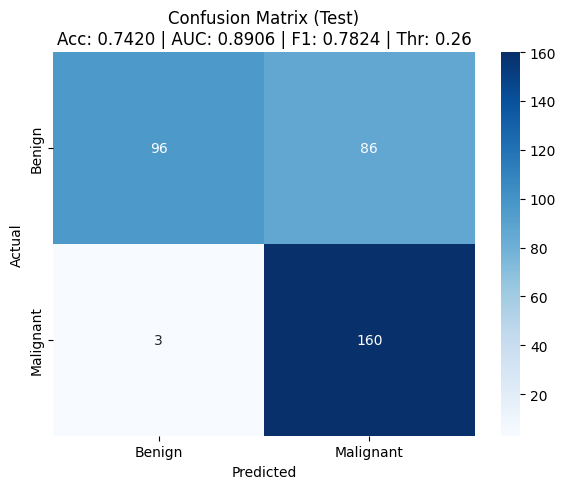

✅ Confusion matrix saved


In [19]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)
plt.title(
    f"Confusion Matrix (Test)\n"
    f"Acc: {test_metrics['accuracy']:.4f} | "
    f"AUC: {test_metrics['auc']:.4f} | "
    f"F1: {test_metrics['f1']:.4f} | "
    f"Thr: {test_metrics['threshold']:.2f}"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=150)
plt.show()

print("✅ Confusion matrix saved")

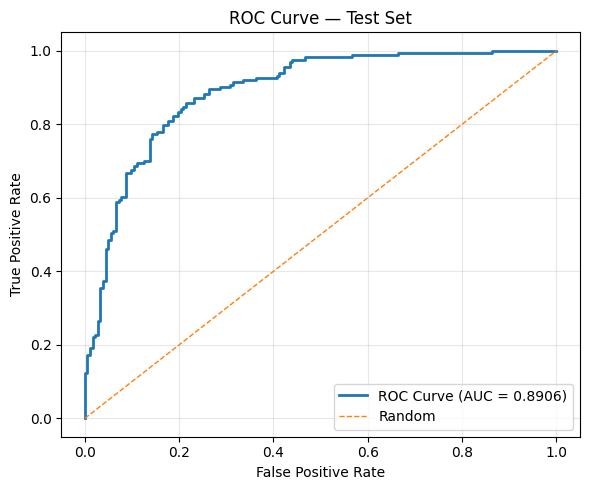

✅ ROC curve saved


In [20]:
fpr, tpr, _ = roc_curve(test_labels, test_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"ROC Curve (AUC = {test_metrics['auc']:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', lw=1, label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Test Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "roc_curve.png"), dpi=150)
plt.show()

print("✅ ROC curve saved")

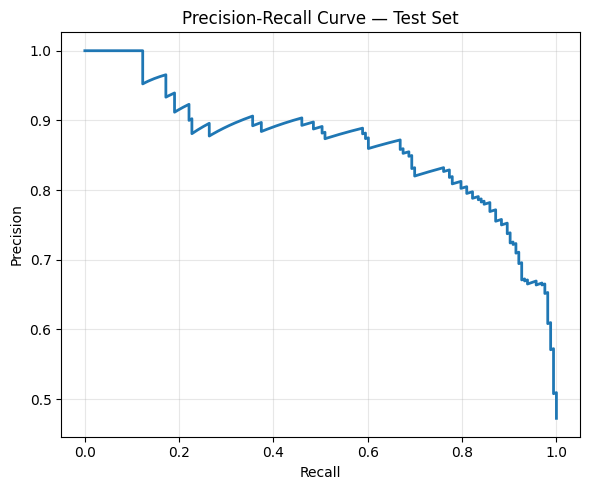

✅ Precision-Recall curve saved


In [21]:
precision, recall, _ = precision_recall_curve(test_labels, test_probs)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Test Set")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "pr_curve.png"), dpi=150)
plt.show()

print("✅ Precision-Recall curve saved")

In [22]:
summary = {
    "model_name": CONFIG["MODEL_NAME"],
    "img_size": CONFIG["IMG_SIZE"],
    "batch_size": CONFIG["BATCH_SIZE"],
    "accum_steps": CONFIG["ACCUM_STEPS"],
    "epochs_run": checkpoint["epoch"],
    "best_val_auc": checkpoint["best_auc"],
    "best_val_f1": checkpoint["best_f1"],
    "best_threshold": checkpoint["best_threshold"],
    "test_accuracy": test_metrics["accuracy"],
    "test_auc": test_metrics["auc"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df)
}

summary_df = pd.DataFrame([summary])
summary_csv_path = os.path.join(SAVE_DIR, "results_summary.csv")
summary_df.to_csv(summary_csv_path, index=False)

print("✅ Results summary saved to:", summary_csv_path)
print(summary_df.T)

✅ Results summary saved to: /content/drive/MyDrive/skin_cancer_project/effv2l_high_accuracy/results_summary.csv
                                                0
model_name      tf_efficientnetv2_l.in21k_ft_in1k
img_size                                      384
batch_size                                      8
accum_steps                                     2
epochs_run                                      4
best_val_auc                             0.909463
best_val_f1                                   0.8
best_threshold                               0.26
test_accuracy                            0.742029
test_auc                                 0.890582
test_precision                           0.650407
test_recall                              0.981595
test_f1                                  0.782396
train_size                                   1608
val_size                                      345
test_size                                     345


In [23]:
def predict_single_image(img_path, model, threshold=0.5):
    image = np.array(Image.open(img_path).convert("RGB"))
    tensor = val_transform(image=image)["image"].unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        with autocast():
            probs = F.softmax(model(tensor), dim=1)[0]

    benign_prob = probs[0].item()
    malignant_prob = probs[1].item()

    pred = 1 if malignant_prob >= threshold else 0
    label = "Malignant" if pred == 1 else "Benign"
    confidence = malignant_prob if pred == 1 else benign_prob

    print(f"Prediction         : {label}")
    print(f"Confidence         : {confidence * 100:.2f}%")
    print(f"Benign Probability : {benign_prob * 100:.2f}%")
    print(f"Malignant Probability: {malignant_prob * 100:.2f}%")
    print(f"Threshold used     : {threshold:.2f}")

    plt.figure(figsize=(5, 5))
    plt.imshow(Image.open(img_path).convert("RGB"))
    plt.axis("off")
    plt.title(f"{label} ({confidence * 100:.2f}%)")
    plt.show()

    return {
        "label": label,
        "confidence": confidence,
        "benign_prob": benign_prob,
        "malignant_prob": malignant_prob,
        "threshold": threshold
    }

Prediction         : Malignant
Confidence         : 26.55%
Benign Probability : 73.45%
Malignant Probability: 26.55%
Threshold used     : 0.26


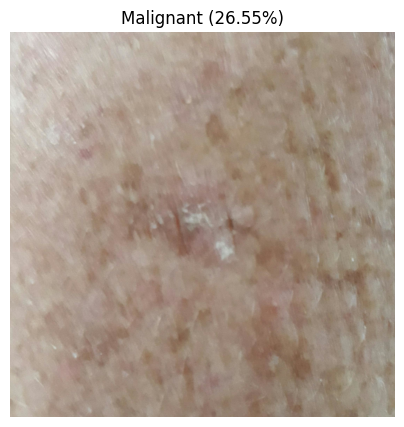

Prediction         : Benign
Confidence         : 89.78%
Benign Probability : 89.78%
Malignant Probability: 10.22%
Threshold used     : 0.26


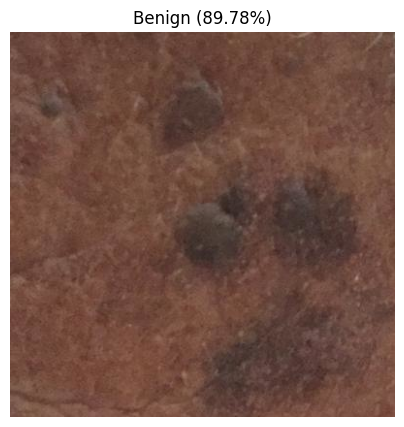

Prediction         : Malignant
Confidence         : 26.34%
Benign Probability : 73.66%
Malignant Probability: 26.34%
Threshold used     : 0.26


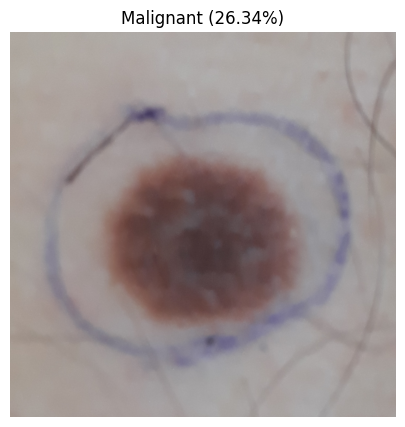

Prediction         : Malignant
Confidence         : 33.80%
Benign Probability : 66.20%
Malignant Probability: 33.80%
Threshold used     : 0.26


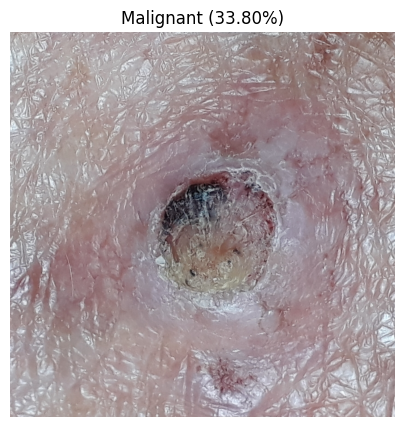

{'label': 'Malignant',
 'confidence': 0.33802250027656555,
 'benign_prob': 0.6619774699211121,
 'malignant_prob': 0.33802250027656555,
 'threshold': np.float64(0.26000000000000006)}

In [26]:
predict_single_image("/content/PAT_1255_876_939.png", model, threshold=best_threshold)
predict_single_image("/content/PAT_1261_896_349.png", model, threshold=best_threshold)
predict_single_image("/content/PAT_621_1182_456.png", model, threshold=best_threshold)
predict_single_image("/content/PAT_86_131_107.png", model, threshold=best_threshold)